# Support Vector Machines

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_csv('../../jupyter_notebooks/DATA/mouse_viral_study.csv')

In [6]:
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


<Axes: xlabel='Med_1_mL', ylabel='Med_2_mL'>

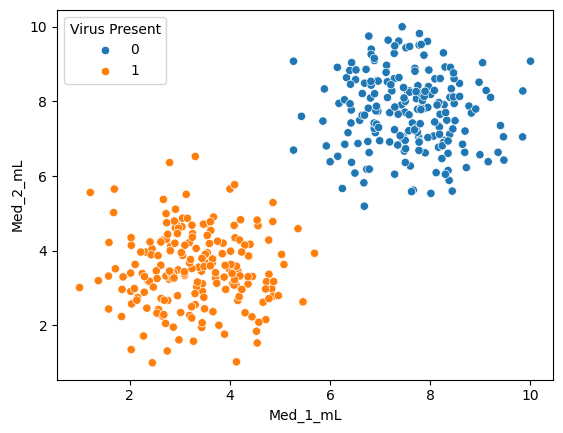

In [7]:
sns.scatterplot(x='Med_1_mL', y='Med_2_mL',hue='Virus Present', data=df)

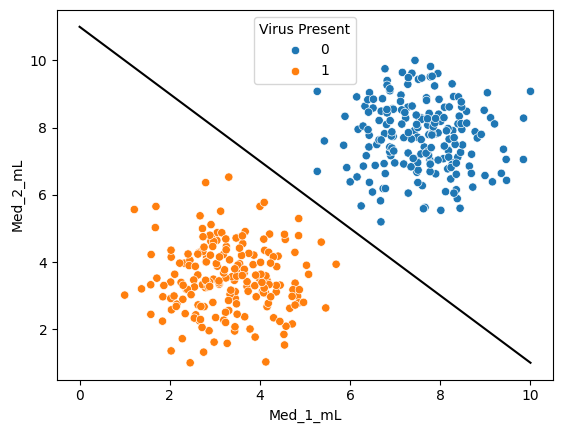

In [8]:
# Create a hyperplane by hand
sns.scatterplot(x='Med_1_mL', y='Med_2_mL',hue='Virus Present', data=df)

x=np.linspace(0,10,100)
m=-1
b=11
y=m*x+b
plt.plot(x,y,'black')


In [9]:
# Now with sklearn
from sklearn.svm import SVC

In [10]:
help(SVC)

Help on class SVC in module sklearn.svm._classes:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(
 |      *,
 |      C=1.0,
 |      kernel='rbf',
 |      degree=3,
 |      gamma='scale',
 |      coef0=0.0,
 |      shrinking=True,
 |      probability=False,
 |      tol=0.001,
 |      cache_size=200,
 |      class_weight=None,
 |      verbose=False,
 |      max_iter=-1,
 |      decision_function_shape='ovr',
 |      break_ties=False,
 |      random_state=None
 |  )
 |
 |  C-Support Vector Classification.
 |
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  The multiclass support is handled according to a

In [11]:
y=df['Virus Present']
X=df.drop('Virus Present',axis=1)

In [12]:
model=SVC(kernel='linear',C=1000)

In [13]:
model.fit(X,y)

,C,1000
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
import sys
sys.path.append('../../jupyter_notebooks/13-Support-Vector-Machines')
from svm_margin_plot import plot_svm_boundary

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


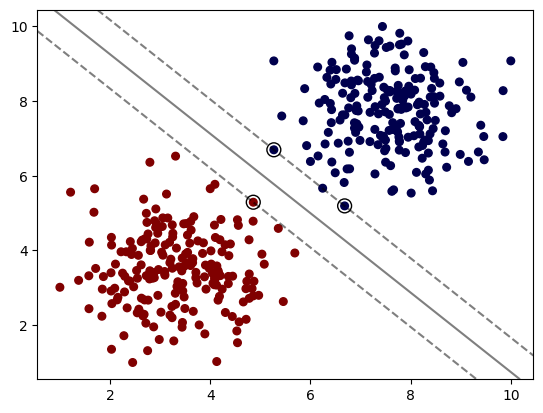

In [15]:
plot_svm_boundary(model,X,y)

### Explore C parameter
How rigid the margins are.

In [16]:
# C parameter, in sklearn, is inversed to be inversely proportional to the points you allow in the margins.
# small C means you allow many points in the margins
model=SVC(kernel='linear',C=0.05)
model.fit(X,y)

,C,0.05
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


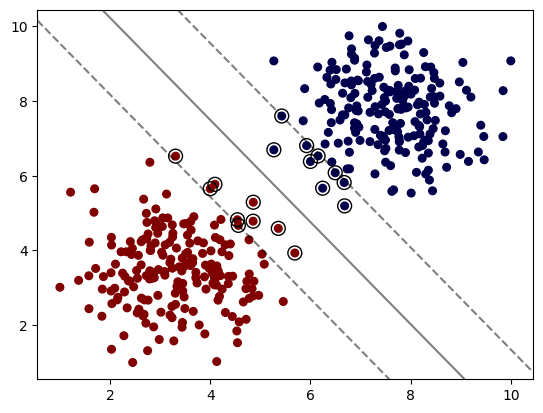

In [17]:
plot_svm_boundary(model,X,y)

In [18]:
model=SVC(kernel='linear',C=0.005)
model.fit(X,y)

,C,0.005
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


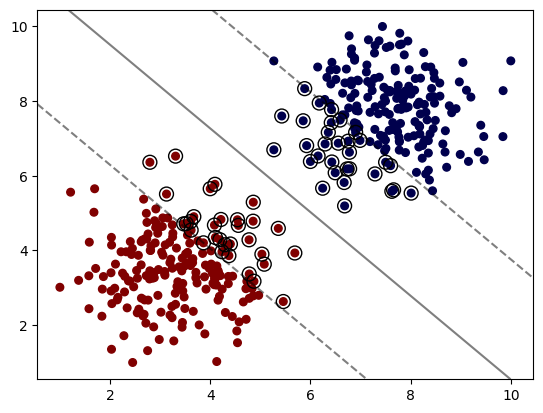

In [19]:
plot_svm_boundary(model,X,y)

### Explore Kernel parameter = rbf.

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


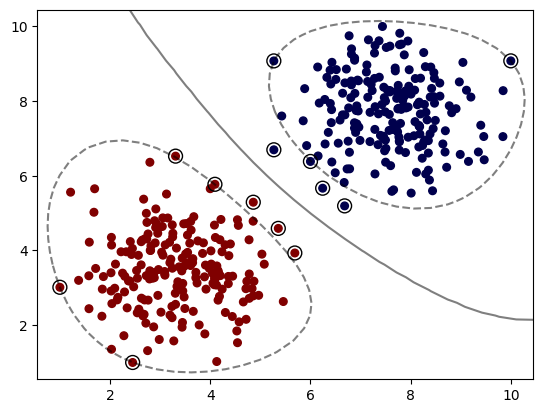

In [20]:
model=SVC(kernel='rbf',C=1)
model.fit(X,y)
plot_svm_boundary(model,X,y)

Let's try a smaller C, more flexible/permeable

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


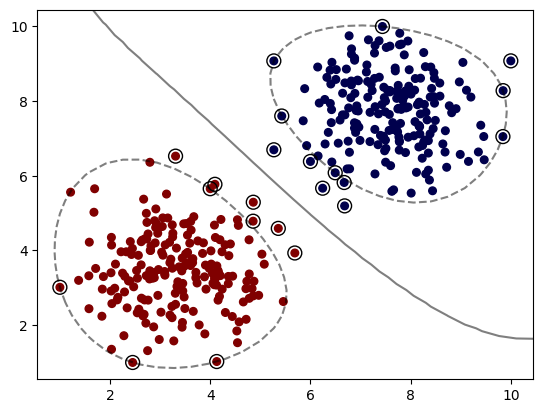

In [21]:
model=SVC(kernel='rbf',C=0.5)
model.fit(X,y)
plot_svm_boundary(model,X,y)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


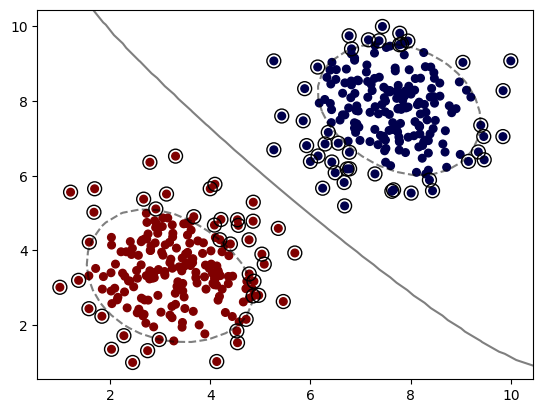

In [22]:
model=SVC(kernel='rbf',C=0.05)
model.fit(X,y)
plot_svm_boundary(model,X,y)

### Let's explore the gamma parameter to SVC()

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


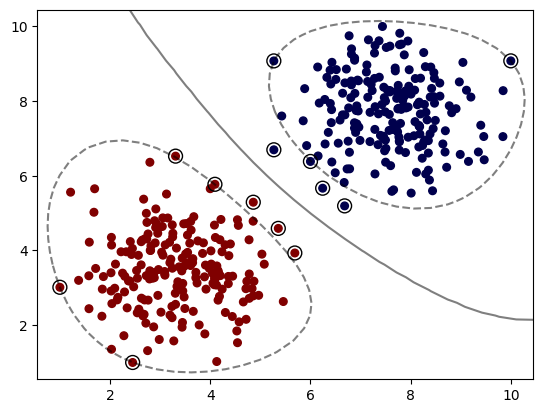

In [23]:
#First with the default value: 'scale'; shall be the same as without the parameter (the first graph with SVC)
model=SVC(kernel='rbf',C=1,gamma='scale')
model.fit(X,y)
plot_svm_boundary(model,X,y)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


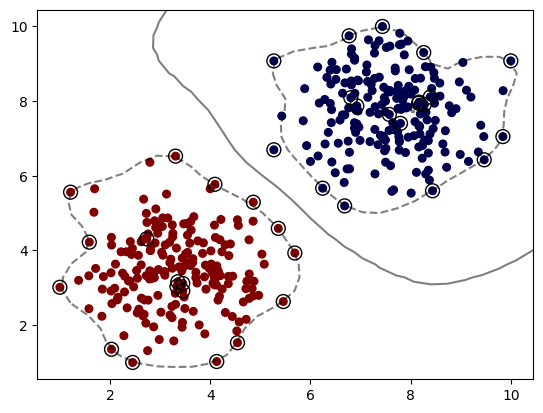

In [24]:
# the larger the gamma the more fitted to the data the margins are
model=SVC(kernel='rbf',C=1,gamma='auto')
model.fit(X,y)
plot_svm_boundary(model,X,y)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


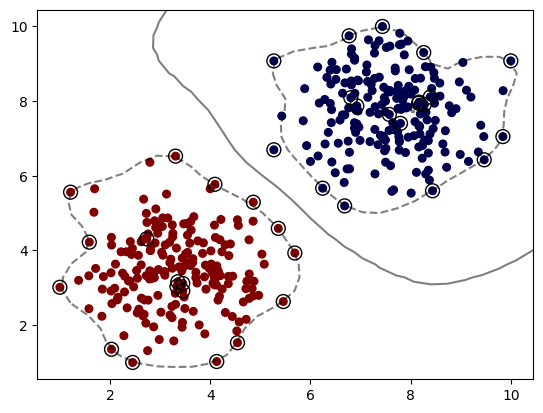

In [25]:
#This is the same as 'scale' used value
model=SVC(kernel='rbf',C=1,gamma=0.5)
model.fit(X,y)
plot_svm_boundary(model,X,y)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


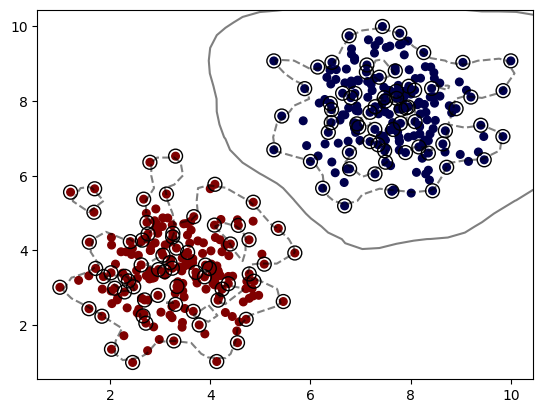

In [26]:
# As we increase the gamma, the margins go fitting the data points more and more.
model=SVC(kernel='rbf',C=1,gamma=2)
model.fit(X,y)
plot_svm_boundary(model,X,y)

### Explore Kernel = sigmoid

In [27]:
model=SVC(kernel='sigmoid')

In [28]:
model.fit(X,y)

,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


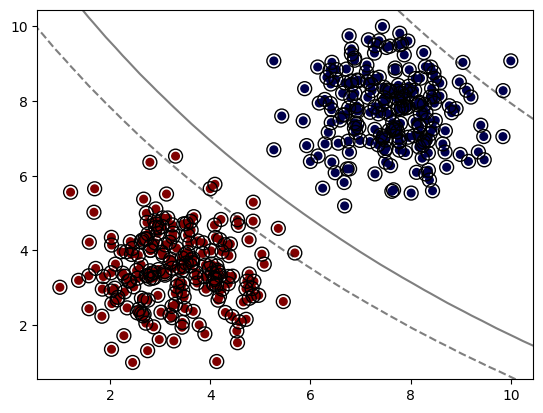

In [29]:
plot_svm_boundary(model,X,y)

### Explore Kernel = polynomial

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


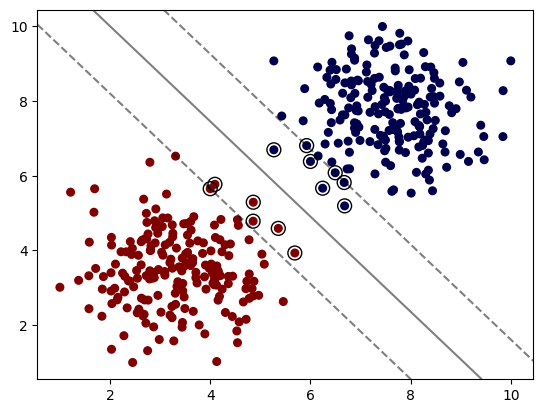

In [30]:
model=SVC(kernel='poly',degree=1)
model.fit(X,y)
plot_svm_boundary(model,X,y)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


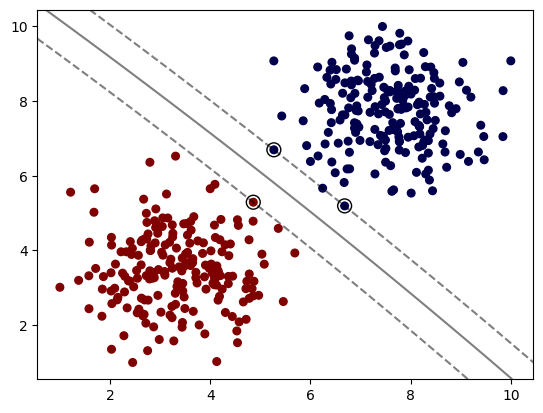

In [31]:
#raising "degree" allows the hyperplane to behave like a more curved line
model=SVC(kernel='poly',degree=2)
model.fit(X,y)
plot_svm_boundary(model,X,y)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


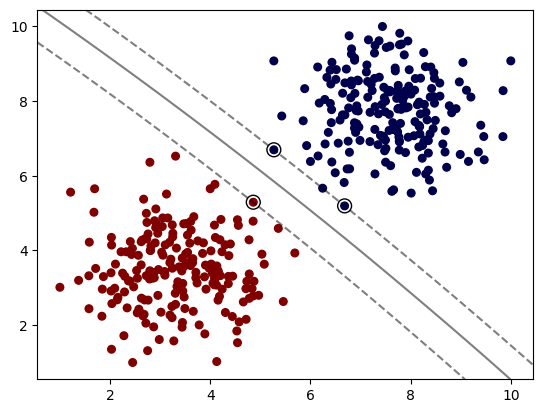

In [32]:
#raising "degree" allows the hyperplane to behave like a more curved line
model=SVC(kernel='poly',degree=3)
model.fit(X,y)
plot_svm_boundary(model,X,y)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


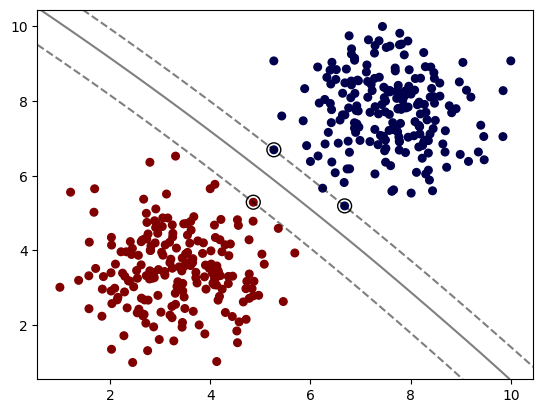

In [33]:
#raising "degree" allows the hyperplane to behave like a more curved line
model=SVC(kernel='poly',degree=4)
model.fit(X,y)
plot_svm_boundary(model,X,y)

## Use GridSeach with SVC

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
svm=SVC()
param_grid={'C':[0.01,0.1,1],'kernel':['linear','rbf']}

In [36]:
grid = GridSearchCV(svm,param_grid)

In [37]:
grid.fit(X,y)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [38]:
grid.best_params_

{'C': 0.01, 'kernel': 'linear'}

# Using Support Vector Machines for Continuous Regression
This is using the hyper param and the margins to fit the known observations of a feature and then, given a new observation, predict what the feature value should be for the observed features. It is not anymore separating classes, but fitting the hyperplane to the features distribution so that it can predict what value should correspond to a new set of featues observed.

In [39]:
df = pd.read_csv('../../jupyter_notebooks/DATA/cement_slump.csv')
df.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,273.0,82.0,105.0,210.0,9.0,904.0,680.0,23.0,62.0,34.99
1,163.0,149.0,191.0,180.0,12.0,843.0,746.0,0.0,20.0,41.14
2,162.0,148.0,191.0,179.0,16.0,840.0,743.0,1.0,20.0,41.81
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,3.0,21.5,42.08
4,154.0,112.0,144.0,220.0,10.0,923.0,658.0,20.0,64.0,26.82


<Axes: >

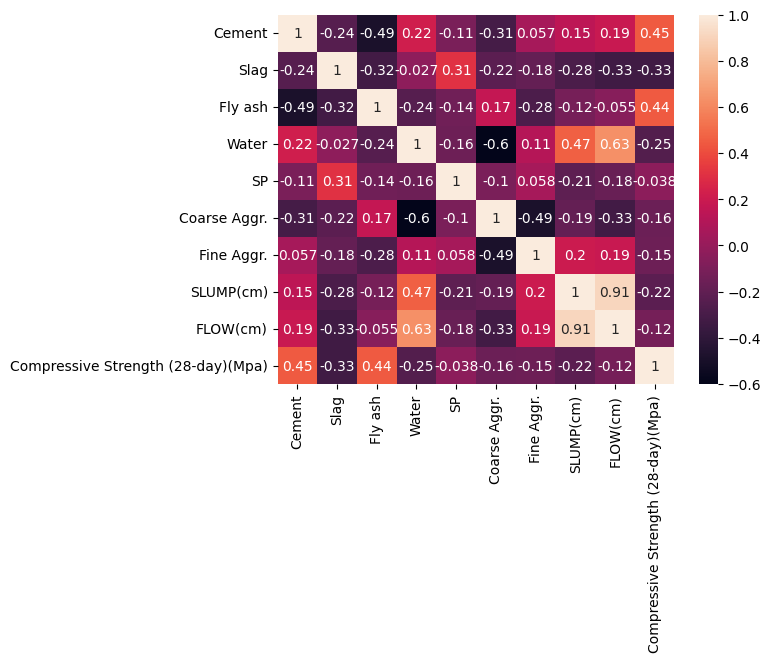

In [41]:
sns.heatmap(df.corr(), annot=True)

In [42]:
df.columns

Index(['Cement', 'Slag', 'Fly ash', 'Water', 'SP', 'Coarse Aggr.',
       'Fine Aggr.', 'SLUMP(cm)', 'FLOW(cm)',
       'Compressive Strength (28-day)(Mpa)'],
      dtype='object')

In [43]:
X=df.drop('Compressive Strength (28-day)(Mpa)',axis=1)
y=df['Compressive Strength (28-day)(Mpa)']

In [44]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In the case of Support Vector Machines it is really recommended to scale your data before using the model.

In general, scaling will never hurt your model and if you are unsure if scaling benefits your model, you might scale by default to be in the safe side.

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
scaler=StandardScaler()

In [53]:
scaled_X_train=scaler.fit_transform(X_train)

In [54]:
scaled_X_test=scaler.transform(X_test)

In [56]:
from sklearn.svm import SVR,LinearSVR #linearSVR is faster if you are sure linear kernel is your choice

In [57]:
help(SVR)

Help on class SVR in module sklearn.svm._classes:

class SVR(sklearn.base.RegressorMixin, sklearn.svm._base.BaseLibSVM)
 |  SVR(
 |      *,
 |      kernel='rbf',
 |      degree=3,
 |      gamma='scale',
 |      coef0=0.0,
 |      tol=0.001,
 |      C=1.0,
 |      epsilon=0.1,
 |      shrinking=True,
 |      cache_size=200,
 |      verbose=False,
 |      max_iter=-1
 |  )
 |
 |  Epsilon-Support Vector Regression.
 |
 |  The free parameters in the model are C and epsilon.
 |
 |  The implementation is based on libsvm. The fit time complexity
 |  is more than quadratic with the number of samples which makes it hard
 |  to scale to datasets with more than a couple of 10000 samples. For large
 |  datasets consider using :class:`~sklearn.svm.LinearSVR` or
 |  :class:`~sklearn.linear_model.SGDRegressor` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  Read more in the :ref:`User Guide <svm_regression>`.
 

In [58]:
base_model=SVR()

In [59]:
base_model.fit(scaled_X_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [60]:
base_preds=base_model.predict(scaled_X_test)

In [61]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [62]:
mean_absolute_error(y_test,base_preds)

5.236902091259178

In [64]:
np.sqrt(mean_squared_error(y_test,base_preds))

np.float64(6.695914838327133)

Seing the error values we obtain with the default values for our model, let's check what is the average we have in the feature we are trying to predict

In [65]:
y_test.mean()

np.float64(36.26870967741935)

The interpretation of whether it is a good performance depends on the domain knowledge (concrete compressive strength).

But for our purpose in this exercise, we just want to try to improve the error levels of our default model by tunning some parameters.

In [66]:
param_grid={'C':[0.001,0.01,0.1,0.5,1],'kernel':['linear','rbf','poly'],'gamma':['scale','auto'],'degree':[2,3,4],'epsilon':[0,0.01,0.1,0.5,1,2]}

In [67]:
from sklearn.model_selection import GridSearchCV

In [68]:
svr=SVR()

In [69]:
grid=GridSearchCV(svr,param_grid)

In [70]:
grid.fit(scaled_X_train,y_train)

,estimator,SVR()
,param_grid,"{'C': [0.001, 0.01, ...], 'degree': [2, 3, ...], 'epsilon': [0, 0.01, ...], 'gamma': ['scale', 'auto'], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [71]:
grid.best_params_

{'C': 1, 'degree': 2, 'epsilon': 2, 'gamma': 'scale', 'kernel': 'linear'}

In [72]:
grid_preds=grid.predict(scaled_X_test)

In [73]:
mean_absolute_error(y_test,grid_preds)

2.5128012210762365

In [74]:
np.sqrt(mean_squared_error(y_test,grid_preds))

np.float64(3.178210305119858)

We've improved quite a bit with respect to the default model.

In practice, when dealing with Support Vector Machines for regression prediction, you might want to launch a large parameters grid search overnight to find a good set of parameters, since having intuition about how all parameters influence the outcome might be a little tricky for this method.